In [13]:
import math
import os
import os.path as osp
import shutil

import cv2
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import random
import torch
import torch.nn.functional as F
import umap
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib
matplotlib.rc("font",family='AR PL UKai CN')


In [14]:
npz_path = "../checkpoints/supcon_models/1219-1/supcon_embeddings_zhenyu_train.npz"
data = np.load(npz_path)
embeddings = data['embeddings']
label_names = data['label_names']
image_paths = data['image_paths']
mask_paths = data['mask_paths']

print(f"Embeddings 形状: {embeddings.shape}")
print(f"样本数量: {len(image_paths)}")
print(f"标签数量: {len(set(label_names))}")
print(f"唯一标签: {list(set(label_names))[:10]}...")  # 显示前10个标签

Embeddings 形状: (9715, 128)
样本数量: 9715
标签数量: 48
唯一标签: [np.str_('氧化'), np.str_('错装3'), np.str_('碰伤'), np.str_('手指印'), np.str_('异物3-杂物、灰尘、黑线'), np.str_('焊烟'), np.str_('飞边'), np.str_('装反3'), np.str_('划伤1'), np.str_('污渍')]...


In [15]:
# 确保 embeddings 是 numpy 数组
if not isinstance(embeddings, np.ndarray):
    embeddings = np.array(embeddings)

# 确保所有路径都是字符串格式
def decode_if_bytes(x):
    """如果是 bytes 类型，解码为字符串"""
    if isinstance(x, bytes):
        return x.decode('utf-8')
    return str(x)

# 转换路径格式
image_paths = [decode_if_bytes(p) for p in image_paths]
mask_paths = [decode_if_bytes(p) for p in mask_paths]
label_names = [decode_if_bytes(l) for l in label_names]

# 验证数据一致性
assert len(image_paths) == len(mask_paths) == len(label_names) == len(embeddings), \
    f"数据长度不一致: images={len(image_paths)}, masks={len(mask_paths)}, labels={len(label_names)}, embeddings={len(embeddings)}"

print(f"✓ 数据预处理完成")
print(f"  - 样本数: {len(image_paths)}")
print(f"  - Embedding 维度: {embeddings.shape[1]}")
print(f"  - 唯一标签数: {len(set(label_names))}")

✓ 数据预处理完成
  - 样本数: 9715
  - Embedding 维度: 128
  - 唯一标签数: 48


In [16]:
unique_labels = list(set(label_names))
sorted(unique_labels)
print(f"Total unique labels: {len(unique_labels)}")
print(f"unique_labels: {unique_labels}")

Total unique labels: 48
unique_labels: ['氧化', '错装3', '碰伤', '手指印', '异物3-杂物、灰尘、黑线', '焊烟', '飞边', '装反3', '划伤1', '污渍', '装配错位', '断焊', '缺口', '开裂', '破损', '多装1', '异物1-人造', '折痕', '起翘1', '焊洞', '异物遮蔽', '装反1', '焊道划伤', '磨花1', '焊渣', '金属丝', '歪斜2', '多装2', '起翘2', '间隙大', '发亮', '歪斜1', '溢胶', '毛刺', '变形1', '磨花2', '划伤2', '压伤', '焊包', 'R角凸起', '焊偏', '变形2', '笔迹', '异物2-黑点', '错装2', '漏装', '装反2', '错装1']


In [17]:
selected_embeddings = []
selected_labels = []
for emb, lb in zip(embeddings, label_names):
    # if lb.startswith("capsule"):
    selected_embeddings.append(emb)
    selected_labels.append(lb)

selected_embeddings = np.stack(selected_embeddings)
print(f"selected_embeddings shape: {selected_embeddings.shape}")
print(f"selected_labels: {set(selected_labels)}")

selected_embeddings shape: (9715, 128)
selected_labels: {'氧化', '错装3', '碰伤', '手指印', '异物3-杂物、灰尘、黑线', '焊烟', '飞边', '装反3', '划伤1', '污渍', '装配错位', '断焊', '缺口', '开裂', '破损', '多装1', '异物1-人造', '折痕', '起翘1', '焊洞', '异物遮蔽', '装反1', '焊道划伤', '磨花1', '焊渣', '金属丝', '歪斜2', '多装2', '起翘2', '间隙大', '发亮', '歪斜1', '溢胶', '毛刺', '变形1', '磨花2', '划伤2', '压伤', '焊包', 'R角凸起', '焊偏', '变形2', '笔迹', '异物2-黑点', '错装2', '漏装', '装反2', '错装1'}


/home/unitx/miniconda3/envs/hjh/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Total unique labels: 48


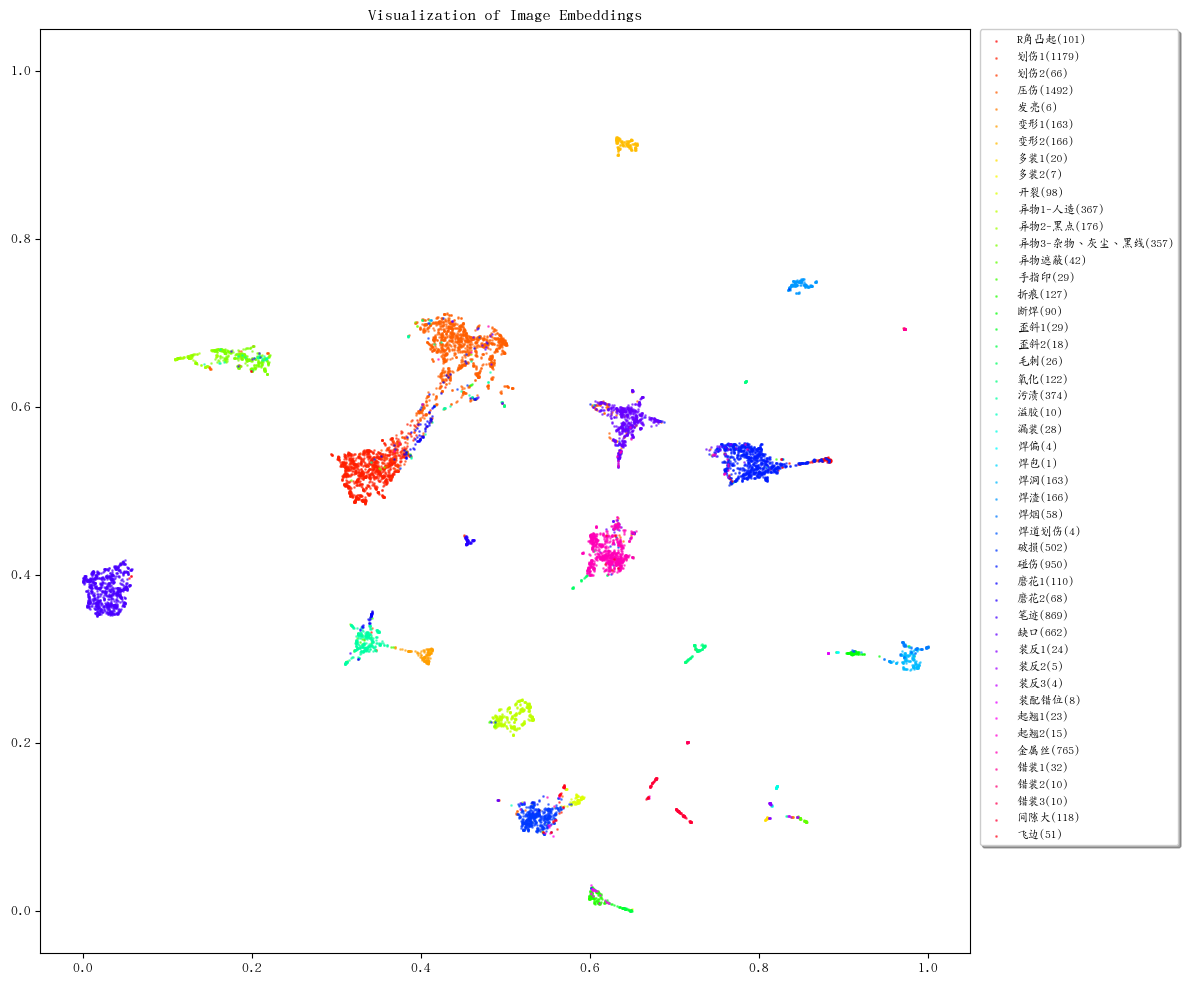

In [ ]:
# reducer = TSNE(
#     n_components=2,
#     perplexity=5,
#     metric='cosine',
#     random_state=42,
# )
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    metric='cosine',
)

embeddings_2d = reducer.fit_transform(selected_embeddings)
# 先将数据移到原点
embeddings_2d[:, 0] = embeddings_2d[:, 0] - embeddings_2d[:, 0].min()
embeddings_2d[:, 1] = embeddings_2d[:, 1] - embeddings_2d[:, 1].min()

# 找到最大的范围作为缩放基准
range_x = embeddings_2d[:, 0].max()
range_y = embeddings_2d[:, 1].max()
max_range = max(range_x, range_y)

# 按照最大范围等比例缩放到 [0, 1]
if max_range > 0:
    embeddings_2d = embeddings_2d / max_range

# 可视化embeddings
unique_selected_labels = list(set(selected_labels))
unique_selected_labels.sort()
print(f"Total unique labels: {len(unique_selected_labels)}")

# 使用更大的色彩映射或生成随机颜色
if len(unique_selected_labels) <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_selected_labels)))
else:
    # 方案1: 使用hsv色彩空间生成足够多的颜色
    colors = plt.cm.hsv(np.linspace(0, 1, len(unique_selected_labels)))

label_to_color = dict(zip(unique_selected_labels, colors))

plt.figure(figsize=(12, 12))
for label in unique_selected_labels:
    mask = np.array([l == label for l in selected_labels])
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=[label_to_color[label]],
        label=label + "({})".format(np.sum(mask)),
        alpha=0.5,
        s=1
    )

plt.legend(
    bbox_to_anchor=(1.01, 1),  # 位置：右上角外侧
    loc='upper left',           # 图例框的参考点
    borderaxespad=0.,          # 图例框与轴的间距
    fontsize='small',          # 字体大小
    frameon=True,              # 显示边框
    fancybox=True,             # 圆角边框
    shadow=True                # 阴影效果
)
plt.title("Visualization of Image Embeddings")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

output_dir = osp.dirname(npz_path)
output_path = osp.join(output_dir, "embeddings_visualization.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图像已保存到: {output_path}")

plt.show()